In [569]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV,lars_path,LassoLarsCV
import matplotlib.pyplot as plt

In [570]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [571]:
# Analyze the original dataset
df_patients_original=pd.read_csv("ML_HW_Data_Patients.csv")
print(df_patients_original.shape)
print('********************************************')
print(df_patients_original.describe())
print('********************************************')
print(df_patients_original.describe(include =object))
print('********************************************')
print(df_patients_original.isnull().sum())
print('********************************************')


(100, 10)
********************************************
              Age   Diastolic      Height      Smoker   Systolic      Weight
count  100.000000  100.000000  100.000000  100.000000  100.00000  100.000000
mean    38.280000   82.960000   67.070000    0.340000  122.78000  154.000000
std      7.215416    6.932459    2.836469    0.476095    6.71284   26.571421
min     25.000000   68.000000   60.000000    0.000000  109.00000  111.000000
25%     32.000000   77.750000   65.000000    0.000000  117.75000  130.750000
50%     39.000000   81.500000   67.000000    0.000000  122.00000  142.500000
75%     44.000000   89.000000   69.250000    1.000000  127.25000  180.250000
max     50.000000   99.000000   72.000000    1.000000  138.00000  202.000000
********************************************
          Gender LastName                   Location SelfAssessedHealthStatus
count        100      100                        100                      100
unique         2      100                          

There is no missing data in the original dataset. 
We can proceed with the analysis without needing to handle missing values. 
Keeping only the relevant columns for further analysis.

In [572]:
df_patients = df_patients_original.drop(['LastName','Diastolic'], axis=1)
print(df_patients.shape)

(100, 8)


In [573]:
# Remove outliers in y (Systolic) first
Q1 = df_patients['Systolic'].quantile(0.25)
Q3 = df_patients['Systolic'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep only non-outlier rows (both X and y)
mask = (df_patients['Systolic'] >= lower_bound) & (df_patients['Systolic'] <= upper_bound)
df_no_outliers = df_patients[mask].copy()

print("Number of outliers removed:", df_patients.shape[0] - df_no_outliers.shape[0])
print("New shape after removing outliers:", df_no_outliers.shape)


Number of outliers removed: 0
New shape after removing outliers: (100, 8)


In [574]:
X_original= df_no_outliers[["Age","Gender","Height","Weight","Smoker","Location","SelfAssessedHealthStatus"]].copy()
Y_original = df_no_outliers["Systolic"].copy()

In [575]:
# standardize numerical data
num_cols = ["Age", "Height", "Weight"]
scaler = StandardScaler()
X_scaled_nums = scaler.fit_transform(X_original[num_cols])
X_original[num_vars] = pd.DataFrame(X_scaled_nums, columns=num_vars, index=X_original.index)
print(X_original.head())
print("*********************************************")
#store the mean and variance for later use
X_num_mean = scaler.mean_
X_num_var = scaler.var_
X_num_std=scaler.scale_
print('test mean: ',X_num_mean)
print('test var: ',X_num_var)
print('test standard deviation: ',X_num_std)

        Age    Gender    Height    Weight  Smoker  \
0 -0.039001    'Male'  1.392506  0.832128       1   
1  0.657450    'Male'  0.683851  0.340416       0   
2 -0.039001  'Female' -1.087784 -0.869952       0   
3  0.239579  'Female' -0.024803 -0.794304       0   
4  1.493193  'Female' -1.087784 -1.323841       0   

                      Location SelfAssessedHealthStatus  
0    'County General Hospital'              'Excellent'  
1                'VA Hospital'                   'Fair'  
2  'St. Mary's Medical Center'                   'Good'  
3                'VA Hospital'                   'Fair'  
4    'County General Hospital'                   'Good'  
*********************************************
test mean:  [ 38.28  67.07 154.  ]
test var:  [ 51.5416   7.9651 698.98  ]
test standard deviation:  [ 7.17924787  2.82225087 26.4382299 ]


In [576]:
#create dummy vars for categorical data
X = pd.get_dummies(
    X_original,
    columns=["Gender", "Location", "SelfAssessedHealthStatus"],
    drop_first=True
)
print(X.head())


        Age    Height    Weight  Smoker  Gender_'Male'  \
0 -0.039001  1.392506  0.832128       1           True   
1  0.657450  0.683851  0.340416       0           True   
2 -0.039001 -1.087784 -0.869952       0          False   
3  0.239579 -0.024803 -0.794304       0          False   
4  1.493193 -1.087784 -1.323841       0          False   

   Location_'St. Mary's Medical Center'  Location_'VA Hospital'  \
0                                 False                   False   
1                                 False                    True   
2                                  True                   False   
3                                 False                    True   
4                                 False                   False   

   SelfAssessedHealthStatus_'Fair'  SelfAssessedHealthStatus_'Good'  \
0                            False                            False   
1                             True                            False   
2                            False 

In [577]:
#creating linear regression model
reg = LinearRegression()
reg.fit(X, Y_original)

print('Coefficients: \n', reg.coef_ ) 


Coefficients: 
 [ 0.57620401  1.32538712 -0.35475725  9.67308711 -1.47939073 -0.85650078
 -1.73484051 -2.75096823  0.58637873  0.45934283]


In [578]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': reg.coef_
}).sort_values('Coefficient', ascending=False)
print(f'\nIntercept: {reg.intercept_:.3f}')
print("*********************************************")
print('Coefficients for all features: \n')
print(coef_df)
print("*********************************************")



Intercept: 121.161
*********************************************
Coefficients for all features: 

                                Feature  Coefficient
3                                Smoker     9.673087
1                                Height     1.325387
8       SelfAssessedHealthStatus_'Good'     0.586379
0                                   Age     0.576204
9       SelfAssessedHealthStatus_'Poor'     0.459343
2                                Weight    -0.354757
5  Location_'St. Mary's Medical Center'    -0.856501
4                         Gender_'Male'    -1.479391
6                Location_'VA Hospital'    -1.734841
7       SelfAssessedHealthStatus_'Fair'    -2.750968
*********************************************


In [579]:
x_train, x_test, y_train, y_test = train_test_split(X, Y_original, test_size = .2, random_state = 1234)

In [580]:
x_train.head()



,Age,Height,Weight,Smoker,Gender_'Male',Location_'St. Mary's Medical Center',Location_'VA Hospital',SelfAssessedHealthStatus_'Fair',SelfAssessedHealthStatus_'Good',SelfAssessedHealthStatus_'Poor'
9,-1.014034,-0.379130,-0.832128,0,False,False,False,False,False,False
51,0.796741,-1.796438,-0.680832,1,False,True,False,False,True,False
29,-1.153324,-0.024803,1.210368,1,True,False,False,False,False,False
88,-1.014034,-0.379130,-0.491712,1,False,False,True,False,True,False
75,-1.014034,1.746833,0.907776,1,True,False,True,True,False,False


In [581]:
x_test.head()

,Age,Height,Weight,Smoker,Gender_'Male',Location_'St. Mary's Medical Center',Location_'VA Hospital',SelfAssessedHealthStatus_'Fair',SelfAssessedHealthStatus_'Good',SelfAssessedHealthStatus_'Poor'
40,0.100289,1.392506,0.378240,1,True,False,False,True,False,False
35,1.353902,-0.379130,-0.643008,0,False,False,True,False,False,False
81,0.100289,0.683851,1.286017,0,True,False,True,False,False,False
61,-1.431905,-0.733457,-1.021248,0,False,False,True,False,True,False
98,0.936031,0.329524,0.680832,1,True,False,False,False,True,False


In [582]:
model = LassoLarsCV(cv=10)
model.fit(x_train, y_train)
print("Best alpha using built-in LassoLarsCV: %f" % model.alpha_)

coef_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(f'\nIntercept: {model.intercept_:.3f}')
print("*********************************************")
print('Coefficients for all features: \n')
print(coef_df)
print("*********************************************")
print('Lasso Scores:')
print('Train ', model.score(x_train, y_train.values.ravel()))
print('Test', model.score(x_test, y_test))



Best alpha using built-in LassoLarsCV: 0.421897

Intercept: 119.832
*********************************************
Coefficients for all features: 

                                Feature  Coefficient
3                                Smoker     8.352177
1                                Height     0.329577
0                                   Age     0.108403
2                                Weight     0.000000
4                         Gender_'Male'     0.000000
5  Location_'St. Mary's Medical Center'     0.000000
6                Location_'VA Hospital'     0.000000
7       SelfAssessedHealthStatus_'Fair'     0.000000
8       SelfAssessedHealthStatus_'Good'     0.000000
9       SelfAssessedHealthStatus_'Poor'     0.000000
*********************************************
Lasso Scores:
Train  0.528836532311346
Test 0.3538214020619953


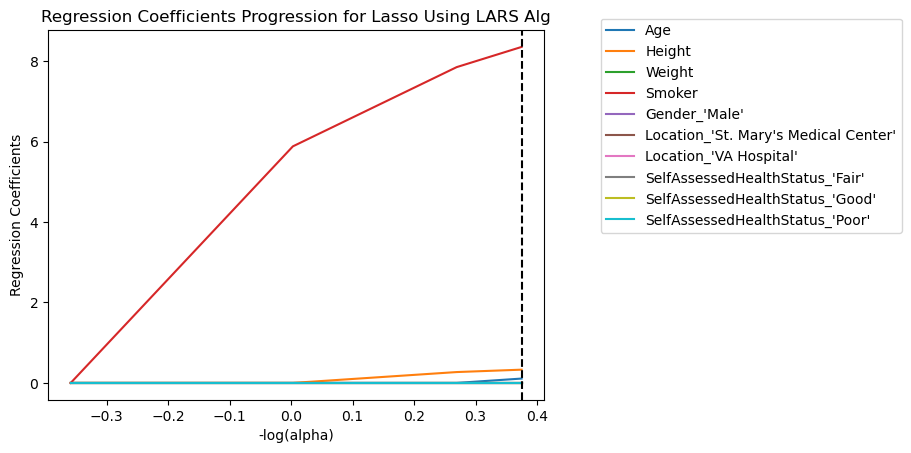

In [583]:
# plot coefficient progression lasso lars
m_log_alphas_lars = -np.log10(model.alphas_)
ax = plt.gca()
plt.plot(m_log_alphas_lars, model.coef_path_.T,label=x_train.columns)
plt.axvline(-np.log10(model.alpha_), linestyle='--', color='k', label='alpha CV')
plt.ylabel('Regression Coefficients')
plt.legend(x_train.columns, bbox_to_anchor=(1.1, 1.05))
plt.xlabel('-log(alpha)')
plt.title('Regression Coefficients Progression for Lasso Using LARS Alg')
plt.show()